# import Statments

In [1]:
!pip uninstall -y tabpfn tabpfn-extensions tabpfn-common-utils
!pip install tabpfn==6.4.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.3/228.3 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
from tabpfn import TabPFNClassifier
import tabpfn
print(tabpfn.__version__)

6.4.1


In [3]:
!pip install "tabpfn-extensions[interpretability]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 128.6 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabpfn_extensions import interpretability

In [5]:
import pandas as pd                    #  data handling
import numpy as np                     #  numerical operations
import matplotlib.pyplot as plt        #  plotting
import seaborn as sns                  #  static data visualization
import plotly.express as px            #  interactive plots
import plotly.graph_objects as go
from scipy.signal import butter, filtfilt, iirnotch
import math
from scipy.stats import zscore
from scipy.stats import median_abs_deviation
import missingno as msno

import warnings
warnings.filterwarnings("ignore")





# Load Data

In [6]:
path = '/content/NCS Data 3. xlsx copy.xlsx'
NCS_df = pd.read_excel(path)

NCS_df.head()

,patient_id,age,sex,side,dominant Hand,Nerve,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms,Diagnosis Severity
0,1,34,F,Right,Right,Ulnar,5.42,3.84,43.5,3.97,4.7,51.7,25.7,Moderate
1,2,61,M,Right,Right,Radial,5.09,4.24,43.3,3.56,9.0,37.3,37.2,Moderate
2,3,40,F,Right,Right,Ulnar,4.01,8.33,46.2,2.76,23.7,58.3,28.1,Normal
3,4,25,F,Right,Right,Ulnar,3.33,12.45,57.6,2.57,15.8,53.8,29.6,Normal
4,5,74,M,Left,Right,Median,3.31,8.98,65.8,3.19,19.7,54.2,21.5,Normal


# EDA

## Data Structure Understanding

In [7]:
print("Shape of the dataset:", NCS_df.shape)

Shape of the dataset: (1020, 14)


In [8]:
print("Columns:", NCS_df.columns)

Columns: Index(['patient_id', 'age', 'sex', 'side', 'dominant Hand', 'Nerve',
       'Motor Latency ms', 'Motor Amplitude mV',
       'Motor Conduction Velocity mps', 'Sensory Latency ms',
       'Sensory Amplitude uV', 'Sensory Conduction Velocity mps',
       'F Wave Latency ms', 'Diagnosis Severity'],
      dtype='object')


In [9]:
print("\nBasic statistics:\n", NCS_df.describe())


Basic statistics:
         patient_id          age  Motor Latency ms  Motor Amplitude mV  \
count  1020.000000  1020.000000       1020.000000         1020.000000   
mean    510.500000    48.558824          4.305755            6.436245   
std     294.592939    16.461317          0.939449            2.191639   
min       1.000000    18.000000          2.400000            0.500000   
25%     255.750000    36.000000          3.580000            4.847500   
50%     510.500000    49.000000          4.145000            6.675000   
75%     765.250000    61.000000          4.930000            8.140000   
max    1020.000000    80.000000          7.800000           12.450000   

       Motor Conduction Velocity mps  Sensory Latency ms  \
count                    1020.000000         1020.000000   
mean                       49.096765            3.594039   
std                         7.728810            0.879832   
min                        24.600000            2.000000   
25%                   

In [10]:
# Data Info + Memory Usage

NCS_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   patient_id                       1020 non-null   int64  
 1   age                              1020 non-null   int64  
 2   sex                              1020 non-null   object 
 3   side                             1020 non-null   object 
 4   dominant Hand                    1020 non-null   object 
 5   Nerve                            1020 non-null   object 
 6   Motor Latency ms                 1020 non-null   float64
 7   Motor Amplitude mV               1020 non-null   float64
 8   Motor Conduction Velocity mps    1020 non-null   float64
 9   Sensory Latency ms               1020 non-null   float64
 10  Sensory Amplitude uV             1020 non-null   float64
 11  Sensory Conduction Velocity mps  1020 non-null   float64
 12  F Wave Latency ms   

In [11]:
#Count numeric & categorical features

# Select numeric & categorical features
numeric_features = NCS_df.select_dtypes(include=['int64', 'float64']).drop(columns=['patient_id'])
categorical_features = NCS_df.select_dtypes(include=['object', 'category'])

# column counts
print("Number of Numeric features:", len(numeric_features.columns))
print("Number of Categorical features:", len(categorical_features.columns))

# column names
print("\nNumeric feature:")
print(list(numeric_features.columns))

print("\nCategorical feature:")
print(list(categorical_features.columns))

Number of Numeric features: 8
Number of Categorical features: 5

Numeric feature:
['age', 'Motor Latency ms', 'Motor Amplitude mV', 'Motor Conduction Velocity mps', 'Sensory Latency ms', 'Sensory Amplitude uV', 'Sensory Conduction Velocity mps', 'F Wave Latency ms']

Categorical feature:
['sex', 'side', 'dominant Hand', 'Nerve', 'Diagnosis Severity']


## Descriptive Summary Statistics

In [12]:
# Summary stats for all numeric features

numeric_cols = NCS_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('patient_id')

NCS_df[numeric_cols].describe().T  # Transpose for readability

,count,mean,std,min,25%,50%,75%,max
age,1020.0,48.558824,16.461317,18.0,36.0000,49.000,61.00,80.00
Motor Latency ms,1020.0,4.305755,0.939449,2.4,3.5800,4.145,4.93,7.80
Motor Amplitude mV,1020.0,6.436245,2.191639,0.5,4.8475,6.675,8.14,12.45
Motor Conduction Velocity mps,1020.0,49.096765,7.728810,24.6,44.1000,49.900,54.90,68.50
Sensory Latency ms,1020.0,3.594039,0.879832,2.0,2.9200,3.400,4.15,6.93
Sensory Amplitude uV,1020.0,20.529902,8.121169,0.5,14.3000,20.900,26.60,44.80
Sensory Conduction Velocity mps,1020.0,48.462843,7.927196,23.8,43.1750,49.450,54.60,66.10
F Wave Latency ms,1020.0,29.483922,4.662453,19.4,26.2000,28.900,32.20,52.70


In [13]:
print( type(numeric_features))
print( type(numeric_cols) )

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.indexes.base.Index'>


## Target Label Distribution

In [14]:
print("Severity distribution:")
print(NCS_df['Diagnosis Severity'].value_counts())

Severity distribution:
Diagnosis Severity
Normal      399
Mild        327
Moderate    199
Severe       95
Name: count, dtype: int64


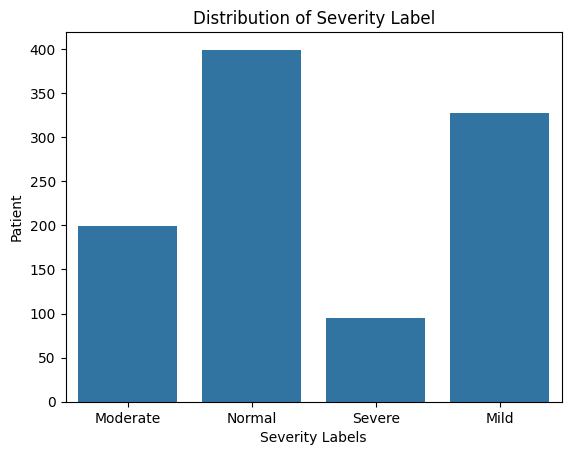

In [15]:
sns.countplot(data=NCS_df, x='Diagnosis Severity')

plt.title('Distribution of Severity Label')
plt.xlabel("Severity Labels")
plt.ylabel("Patient")
plt.show()

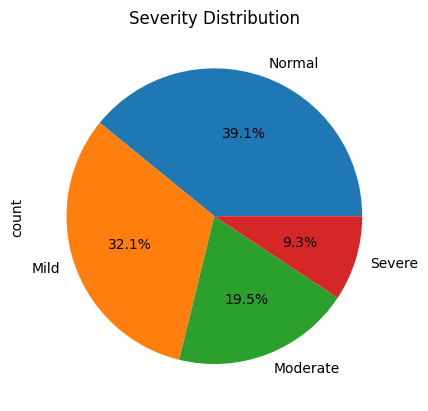

In [16]:
NCS_df['Diagnosis Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Severity Distribution")
plt.show()

## Correlation Analysis

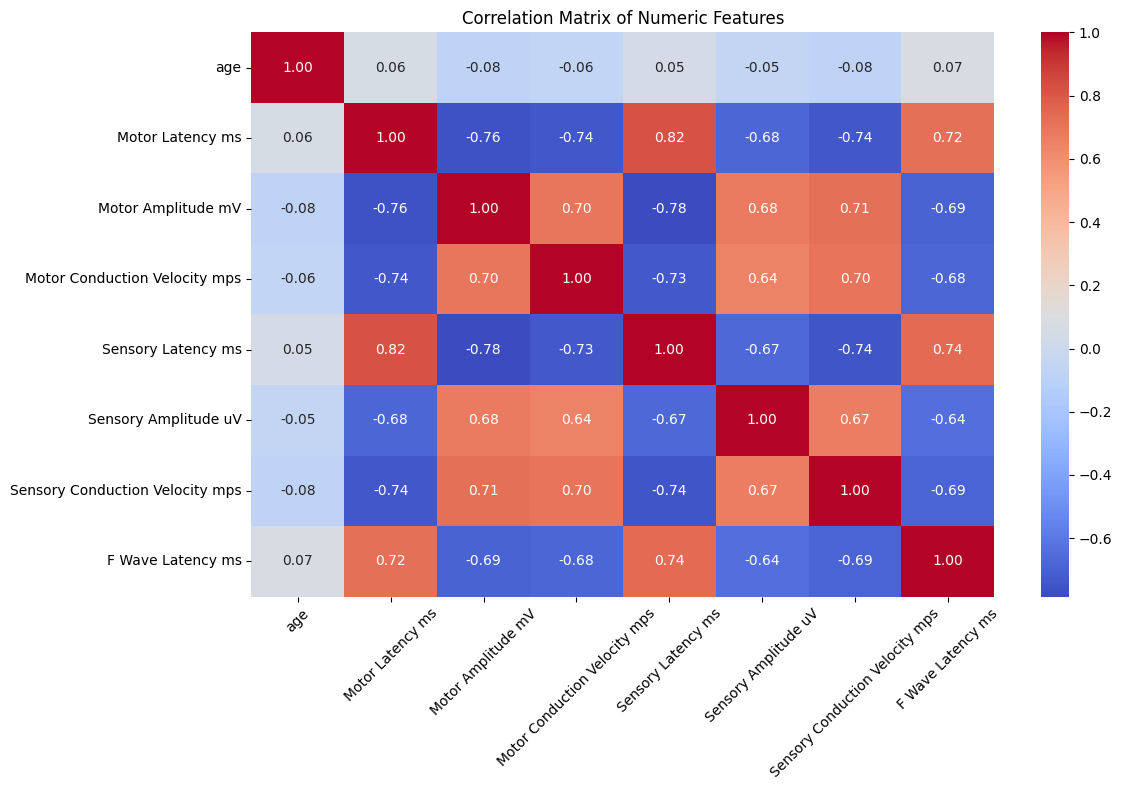

In [17]:
# Correlation matrix to detect collinear features

corr = NCS_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Distribution of Each NCS Feature

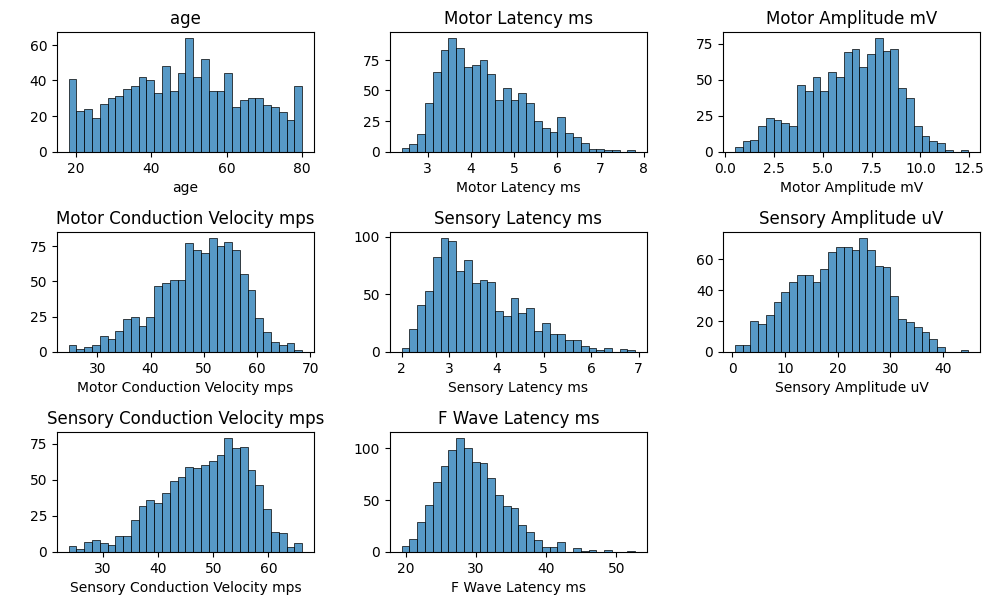

In [18]:
# number of charts per row
cols = 3

# round up the number of rows ; Ensures enough rows to display all features.
rows = math.ceil( len(numeric_features) / cols)

# Create Creates a new figure for all subplots ( witdh,height  )
plt.figure(figsize=(10, rows * 2))


for i, col in enumerate(numeric_features, 1):
    #Creates the i-th subplot in a grid of rows × cols.
    plt.subplot(rows, cols, i)

    # draws histogram + dropna() removes missing values before plottin + splits the data range into 30 buckets +  no density curve
    sns.histplot(NCS_df[col].dropna(), bins=30, kde=False)
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)
    plt.ylabel(' ', fontsize=10)

plt.tight_layout()
plt.show()

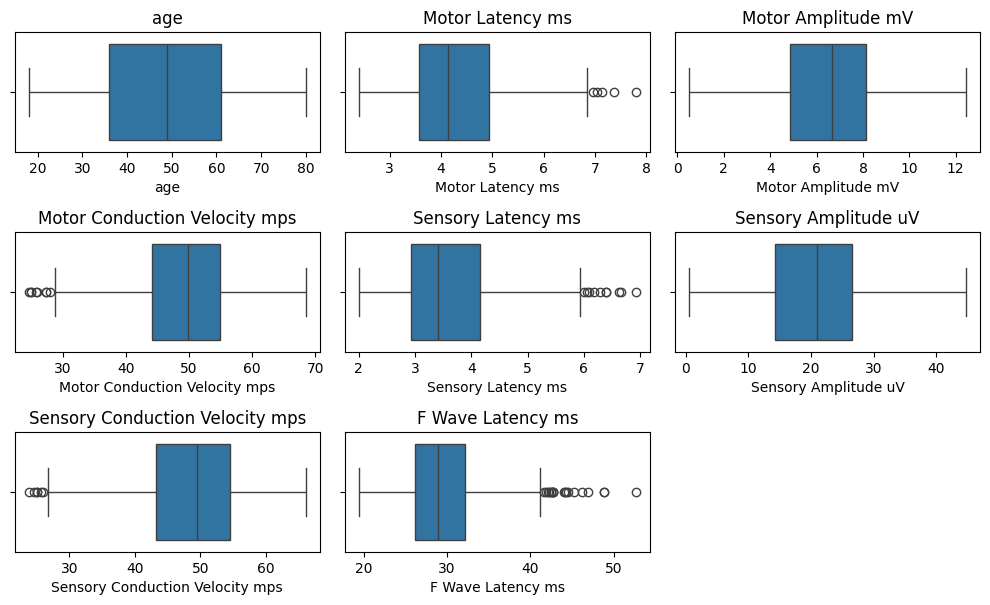

In [19]:
#  Boxplot by Nerve or Severity

plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=NCS_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

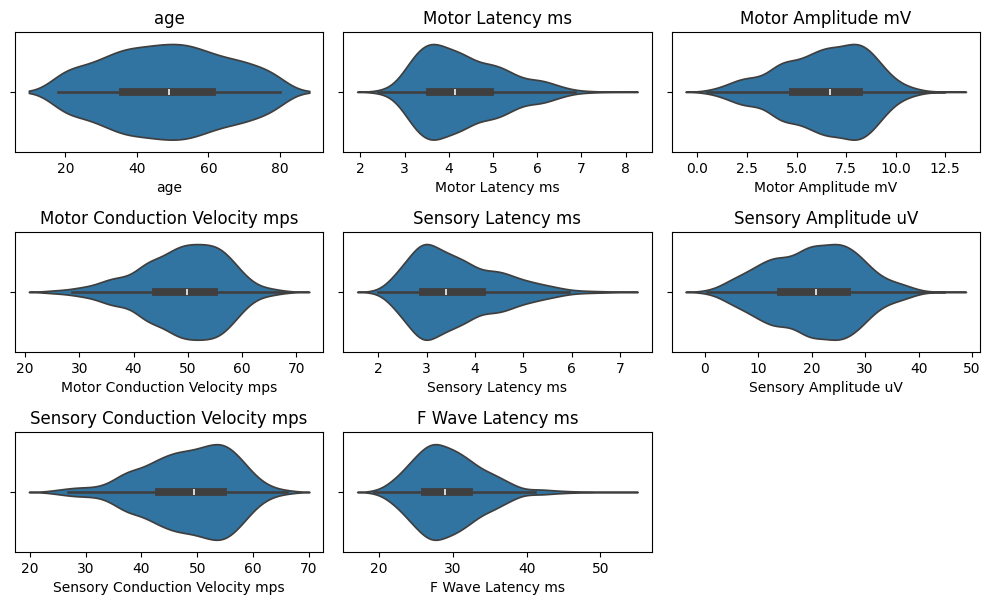

In [20]:
#Violin Plot
plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.violinplot(x=NCS_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### Catagorical Features Distribution

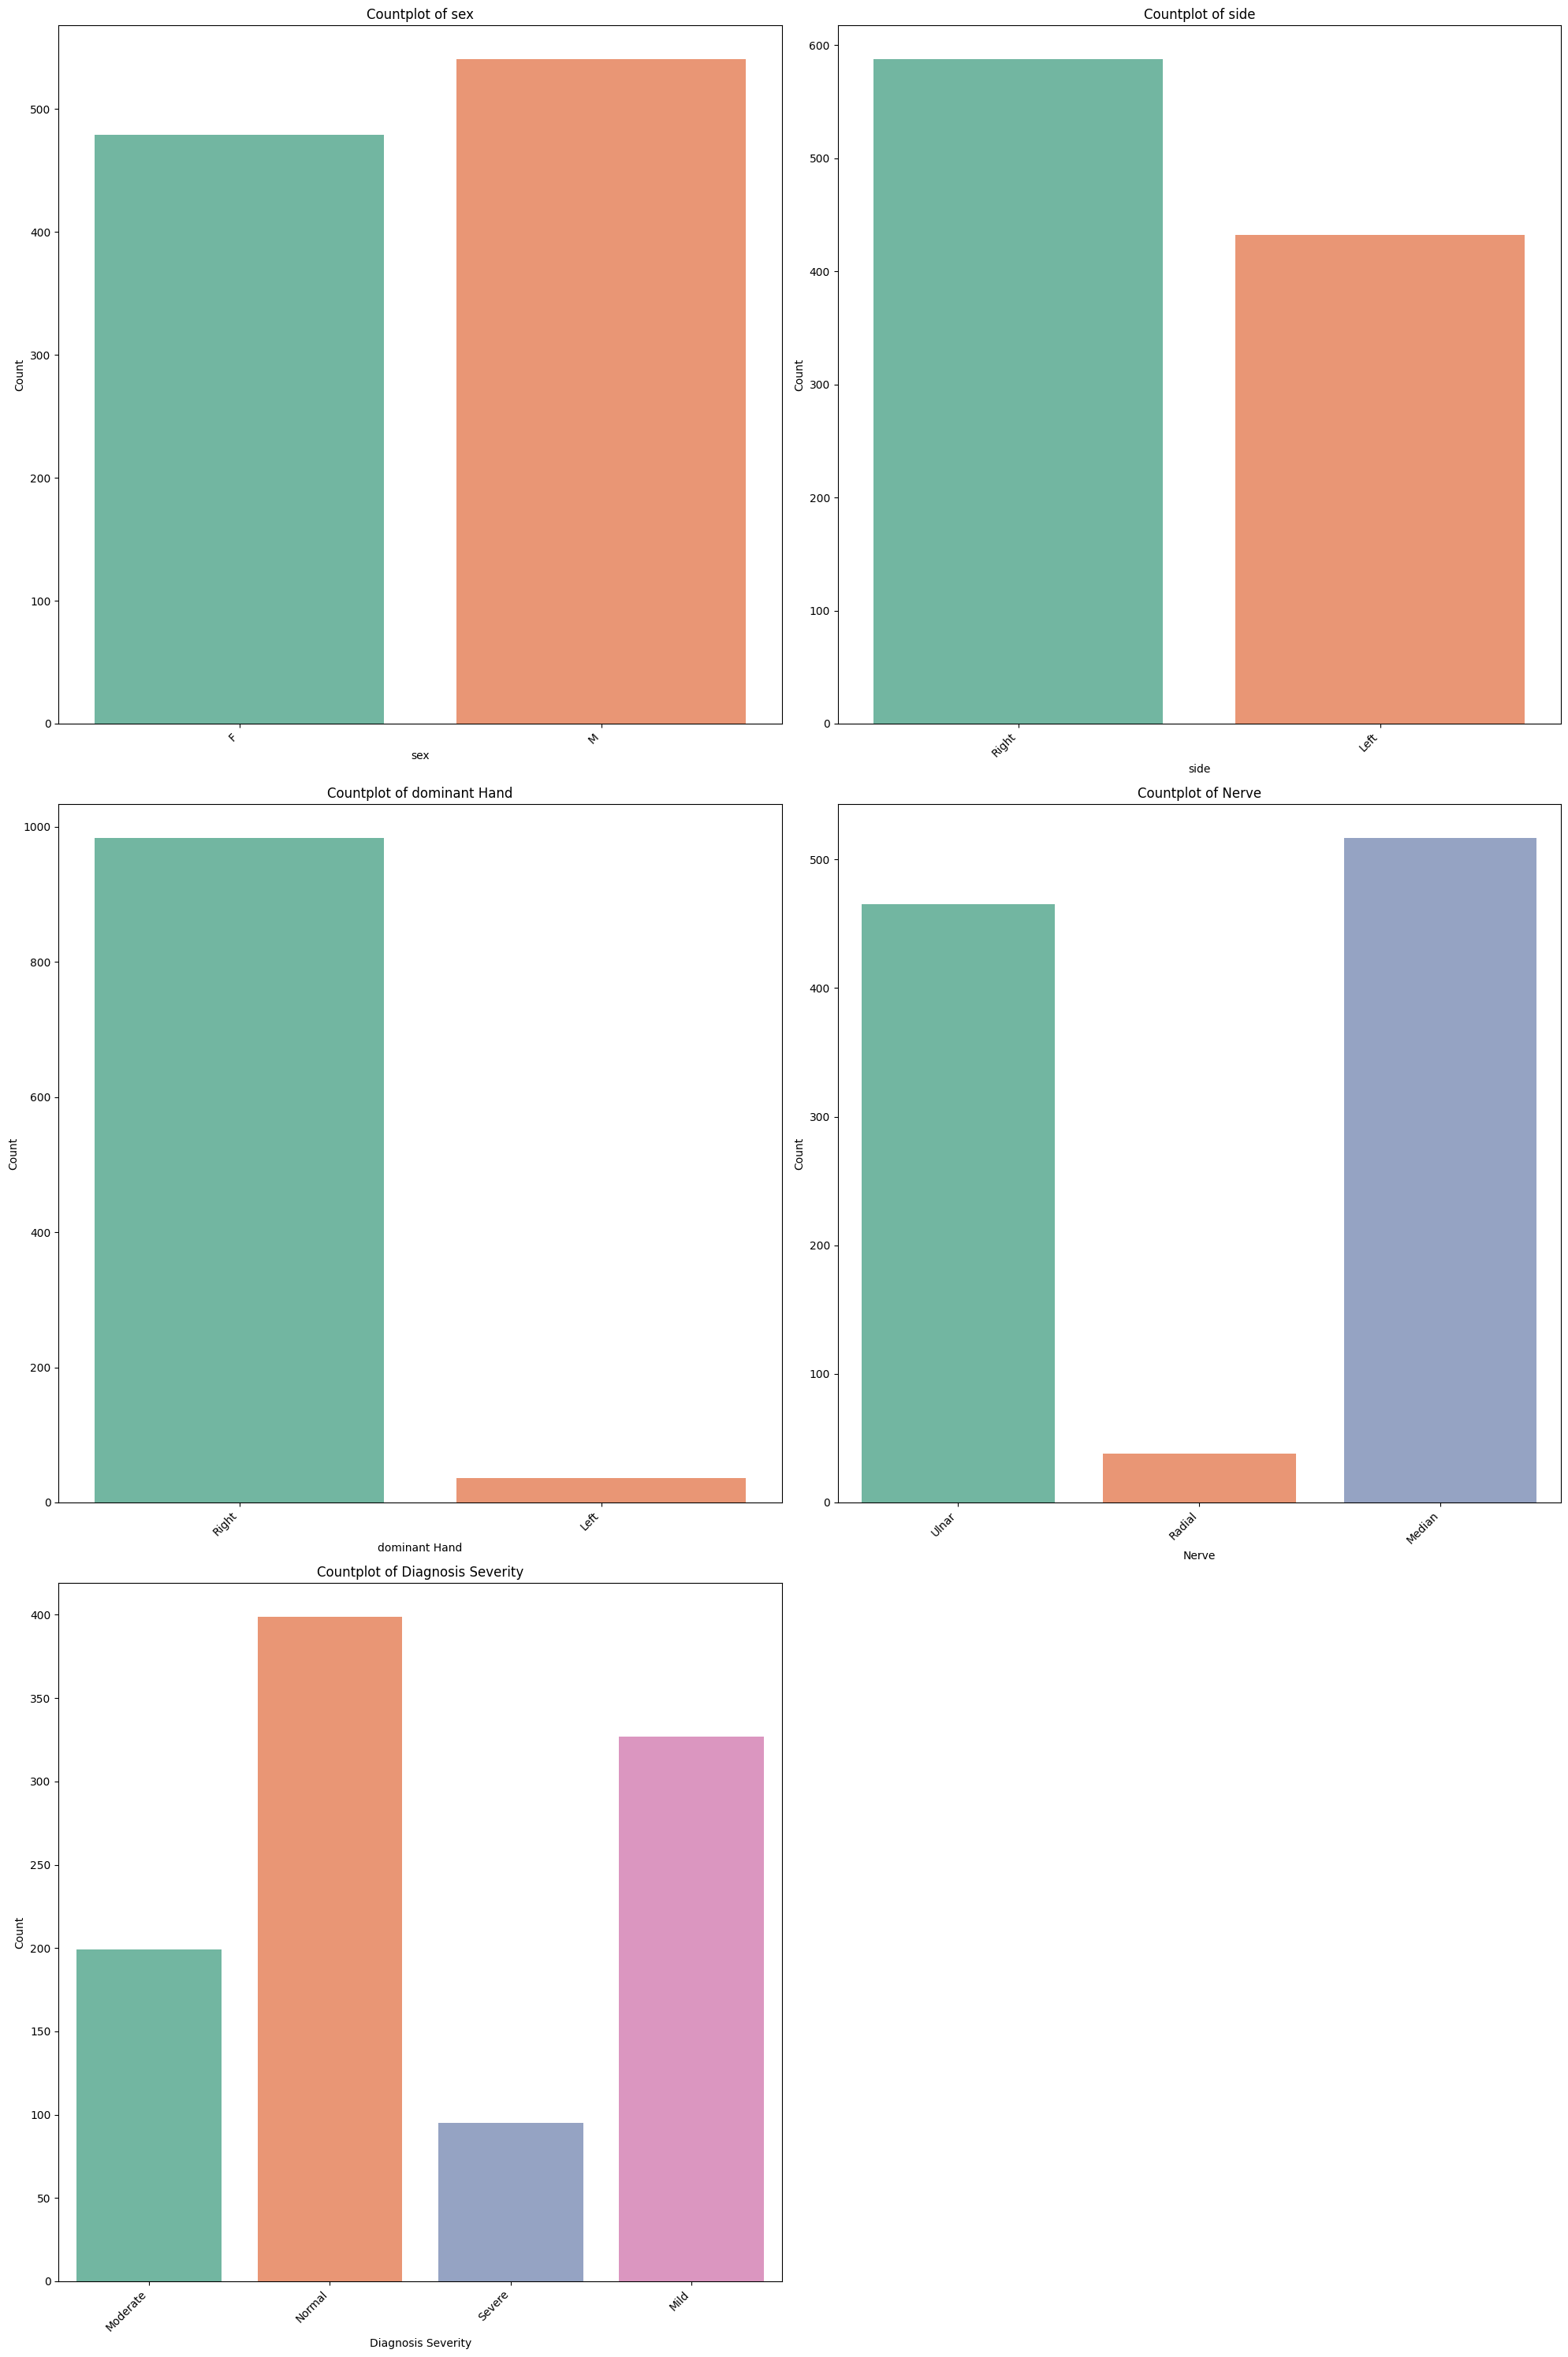

In [21]:
# Count Plot

# Select categorical columns
categorical_cols = NCS_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Layout
cols = 2   # number of plots per row
rows = math.ceil(n_cat / cols)

# Create figure
plt.figure(figsize=(20, rows * 10))

# Loop for subplots
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=NCS_df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

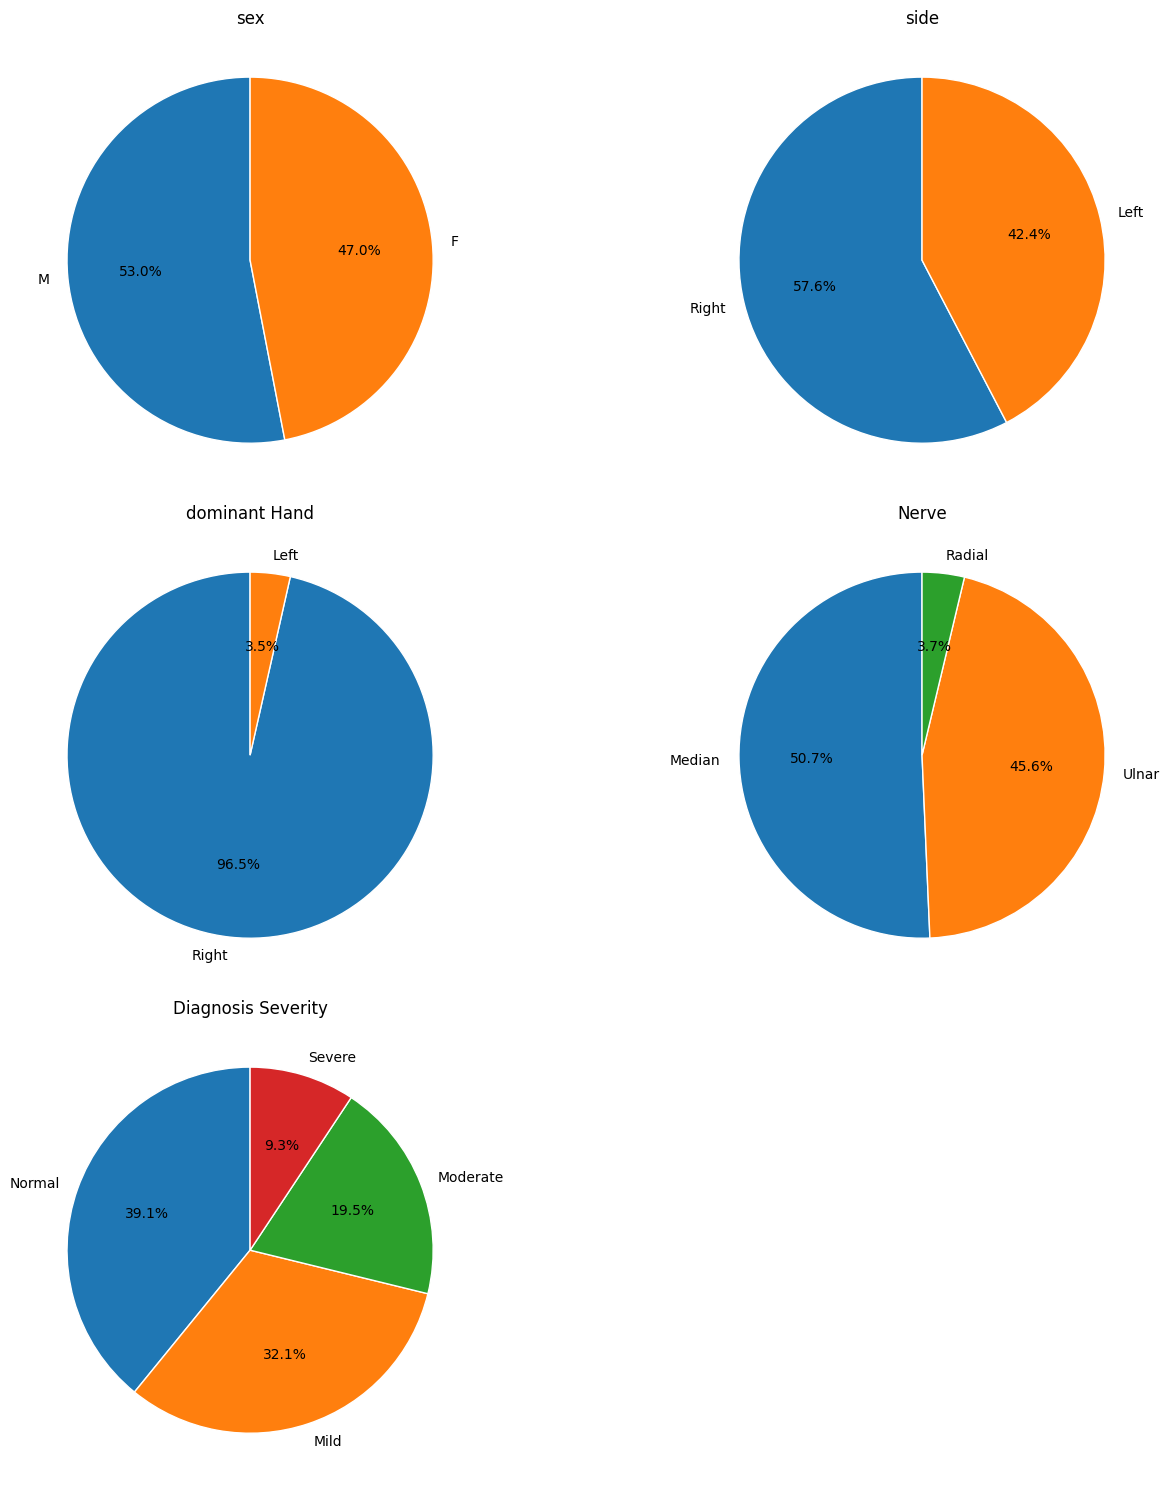

In [22]:
# Pie chart

# Select categorical columns
categorical_cols = NCS_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Subplot layout
cols = 2
rows = math.ceil(n_cat / cols)

# Create the figure
plt.figure(figsize=(14, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Get counts
    data = NCS_df[col].value_counts()

    # Pie chart
    plt.pie(
        data.values,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

## Missing Values

In [23]:
print("Missing values per column:\n", NCS_df.isnull().sum()) #Nan None

Missing values per column:
 patient_id                         0
age                                0
sex                                0
side                               0
dominant Hand                      0
Nerve                              0
Motor Latency ms                   0
Motor Amplitude mV                 0
Motor Conduction Velocity mps      0
Sensory Latency ms                 0
Sensory Amplitude uV               0
Sensory Conduction Velocity mps    0
F Wave Latency ms                  0
Diagnosis Severity                 0
dtype: int64


## Duplicates Recoreds


In [24]:
dup_rows = NCS_df.duplicated().sum()
print("\nNumber of Fully Duplicated rows:", dup_rows)


Number of Fully Duplicated rows: 0


## Detecting Messy Format

In [25]:
# Detect Non-Numeric Characters Inside Numeric Columns

for col in NCS_df.select_dtypes(include='object'):
    # Check if column is supposed to be numeric
    try:
        NCS_df[col].astype(float)
        print(f"POSSIBLE WRONG FORMAT → {col}: contains numeric-like strings")
    except:
        pass


In [26]:
# Detect Leading / Trailing Spaces

for col in NCS_df.select_dtypes(include='object'):
    NCS_df[col] = NCS_df[col].astype(str)
    if NCS_df[col].str.contains(r'^\s+|\s+$').any():
        print(f"WARNING: Spaces in {col}")

In [27]:
# Detect Mixed Formats

for col in NCS_df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(NCS_df[col].unique())


Unique values in sex:
['F' 'M']

Unique values in side:
['Right' 'Left']

Unique values in dominant Hand:
['Right' 'Left']

Unique values in Nerve:
['Ulnar' 'Radial' 'Median']

Unique values in Diagnosis Severity:
['Moderate' 'Normal' 'Severe' 'Mild']


In [28]:
# Detect Unexpected / Invalid Categories

for col in NCS_df.select_dtypes(include='object'):
    print(f"\n{col} → unique values:")
    print(NCS_df[col].value_counts(dropna=False))


sex → unique values:
sex
M    541
F    479
Name: count, dtype: int64

side → unique values:
side
Right    588
Left     432
Name: count, dtype: int64

dominant Hand → unique values:
dominant Hand
Right    984
Left      36
Name: count, dtype: int64

Nerve → unique values:
Nerve
Median    517
Ulnar     465
Radial     38
Name: count, dtype: int64

Diagnosis Severity → unique values:
Diagnosis Severity
Normal      399
Mild        327
Moderate    199
Severe       95
Name: count, dtype: int64


In [29]:
# Detect Columns with Mixed Types

for col in NCS_df.columns:
    types = NCS_df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")

In [30]:
# Detect Symbols or Patterns in Categorical Columns

import re

for col in NCS_df.select_dtypes(include='object'):
    if NCS_df[col].str.contains(r'\(|\)|\+|\-').any():
        print(f"Possible encoded scale in {col}")

# Preprocessing

##**Encoding**

In [31]:
NCS_encoded = NCS_df.copy()

###1) **Binary Encoding**

In [32]:
# Encode binary categorical variables using Mapping

NCS_encoded['sex'] = NCS_encoded['sex'].map({
    'M': 1,
    'F': 0
})

NCS_encoded['side'] = NCS_encoded['side'].map({
    'Right': 1,
    'Left': 0
})

NCS_encoded['dominant Hand'] = NCS_encoded['dominant Hand'].map({
    'Right': 1,
    'Left': 0
})

###**2) cat.codes**

In [33]:
NCS_encoded['Nerve'] = NCS_encoded['Nerve'].astype('category').cat.codes

###**3) Ordinal Encoding**

In [34]:
# Encode the target variable (Diagnosis Severity)

NCS_encoded['Diagnosis Severity'] = NCS_encoded['Diagnosis Severity'].map({
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

##Arrange Cols

In [35]:
# Define the target column (the variable we want the model to predict)
target = 'Diagnosis Severity'


# Create a list of columns where the target column is placed at the end
# First take all columns except the target, then add the target column last
cols = [col for col in NCS_encoded.columns if col != target] + [target]


# Reorder the dataframe columns based on the new column list to ensures the target variable appears as the last column
NCS_encoded = NCS_encoded[cols]


# Display the first 5 rows of the dataframe to verify the new column order
NCS_encoded.head()

,patient_id,age,sex,side,dominant Hand,Nerve,Motor Latency ms,Motor Amplitude mV,Motor Conduction Velocity mps,Sensory Latency ms,Sensory Amplitude uV,Sensory Conduction Velocity mps,F Wave Latency ms,Diagnosis Severity
0,1,34,0,1,1,2,5.42,3.84,43.5,3.97,4.7,51.7,25.7,2
1,2,61,1,1,1,1,5.09,4.24,43.3,3.56,9.0,37.3,37.2,2
2,3,40,0,1,1,2,4.01,8.33,46.2,2.76,23.7,58.3,28.1,0
3,4,25,0,1,1,2,3.33,12.45,57.6,2.57,15.8,53.8,29.6,0
4,5,74,1,0,1,0,3.31,8.98,65.8,3.19,19.7,54.2,21.5,0


In [36]:
# Debug

# Check data types to ensure encoding worked correctly
NCS_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   patient_id                       1020 non-null   int64  
 1   age                              1020 non-null   int64  
 2   sex                              1020 non-null   int64  
 3   side                             1020 non-null   int64  
 4   dominant Hand                    1020 non-null   int64  
 5   Nerve                            1020 non-null   int8   
 6   Motor Latency ms                 1020 non-null   float64
 7   Motor Amplitude mV               1020 non-null   float64
 8   Motor Conduction Velocity mps    1020 non-null   float64
 9   Sensory Latency ms               1020 non-null   float64
 10  Sensory Amplitude uV             1020 non-null   float64
 11  Sensory Conduction Velocity mps  1020 non-null   float64
 12  F Wave Latency ms   

##**Train/Test Split**

In [37]:
from sklearn.model_selection import train_test_split

# Separate
X = NCS_encoded.drop(columns=['Diagnosis Severity'])

# target variable
y = NCS_encoded['Diagnosis Severity']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Feature matrix (input variables)
    y,                 # Target variable
    test_size=0.2,     # 20% of the data will be used for testing
    random_state=42,   # Ensures reproducibility (same split every run)
    stratify=y         # Keeps the same class distribution in train and test sets
)

##**Feature Selection**

###1) Statistical Feature Selection

**1) Kruskal-Wallis Test For The Numeric Feature**

In [38]:
from scipy.stats import kruskal
import pandas as pd

# List of numerical features to test their relationship with the target variable
numeric_features = [
    'age',
    'Motor Latency ms',
    'Motor Amplitude mV',
    'Motor Conduction Velocity mps',
    'Sensory Latency ms',
    'Sensory Amplitude uV',
    'Sensory Conduction Velocity mps',
    'F Wave Latency ms'
]

# List to store test results
results = []

# Loop through each numeric feature
for feature in numeric_features:

    # Create a list that will hold the values of the feature for each class of the target
    groups = []

    # For each class in the target variable (Diagnosis Severity)
    for cls in y_train.unique():
        # Select values of the feature corresponding to that class
        groups.append(X_train[y_train == cls][feature])

    # Apply the Kruskal-Wallis test to compare distributions across groups
    stat, p = kruskal(*groups)

    # Store the feature name and its p-value
    results.append({
        'Feature': feature,
        'p-value': p
    })

# Convert results into a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Mark features as significant if p-value ≤ 0.05
results_df["Significant (p≤0.05)"] = results_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Sort features by p-value (most significant first)
results_df = results_df.sort_values("p-value")

# Display the results
results_df

,Feature,p-value,Significant (p≤0.05)
4,Sensory Latency ms,3.096276e-142,Yes
1,Motor Latency ms,2.826092e-136,Yes
2,Motor Amplitude mV,9.926927e-127,Yes
6,Sensory Conduction Velocity mps,1.372064e-122,Yes
3,Motor Conduction Velocity mps,6.061694e-117,Yes
7,F Wave Latency ms,7.917187e-115,Yes
5,Sensory Amplitude uV,6.455790e-107,Yes
0,age,2.927637e-01,No


2) **Chi-Square Test For The Categorical Features**

In [39]:
from scipy.stats import chi2_contingency
import pandas as pd

# List of categorical features to test their relationship with the target
categorical_features = [
    'sex',
    'side',
    'dominant Hand',
    'Nerve'
]

# List to store chi-square test results
chi_results = []

# Loop through each categorical feature
for feature in categorical_features:

    # Create a contingency table between the feature and the target variable
    table = pd.crosstab(X_train[feature], y_train)

    # Perform the Chi-Square test of independence
    chi2, p, dof, expected = chi2_contingency(table)

    # Store the feature name and its p-value
    chi_results.append({
        "Feature": feature,
        "p-value": p
    })

# Convert results into a DataFrame
chi_df = pd.DataFrame(chi_results)

# Sort features by p-value (most significant first)
chi_df = chi_df.sort_values("p-value")

# Mark features as significant if p-value ≤ 0.05
chi_df["Significant (p≤0.05)"] = chi_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Display the results
chi_df

,Feature,p-value,Significant (p≤0.05)
1,side,0.017817,Yes
3,Nerve,0.376711,No
2,dominant Hand,0.502740,No
0,sex,0.657220,No


###2) Fisher Score

In [40]:
# ANOVA F-test function
from sklearn.feature_selection import f_classif
import pandas as pd


# Apply the ANOVA F-test between each feature in X_train and the target variable y_train
# This test evaluates whether the mean values of a feature differ significantly across target classes
f_scores, p_values = f_classif(
    X_train,
    y_train
    )


# create Df to organize the results
fisher_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Fisher Score': f_scores,
    'p-value': p_values
})


# Sort descending order : Higher Fisher Score indicates stronger relationship with the target variable
fisher_df = fisher_df.sort_values(by='Fisher Score', ascending=False)



fisher_df

,Feature,Fisher Score,p-value
9,Sensory Latency ms,1193.249526,4.805988e-297
6,Motor Latency ms,1089.560350,4.279202e-284
7,Motor Amplitude mV,761.318517,2.033985e-235
11,Sensory Conduction Velocity mps,637.727476,6.161237e-213
8,Motor Conduction Velocity mps,527.852767,3.221924e-190
12,F Wave Latency ms,494.325031,1.165408e-182
10,Sensory Amplitude uV,402.478969,3.999860e-160
3,side,3.388733,1.765957e-02
5,Nerve,1.400917,2.412141e-01
1,age,1.009231,3.879516e-01


# ________________________________________________________________________________________________________

#Model Implementation - Baseline

##TabPFN

##### Cross Vaildation Function

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier


def run_tabpfn_stratified_cv(X, y, experiment_name):
    # Copy features to avoid changing original data
    X = X.copy()
    X.columns = X.columns.str.replace(' ', '_')

    # Define target mapping
    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    # Convert y if it is still text labels
    if y.dtype == 'object':
        y = y.map(target_mapping)

    # Keep class order fixed
    sorted_classes = sorted(target_mapping.items(), key=lambda x: x[1])
    class_names = [name for name, _ in sorted_classes]
    class_labels = [label for _, label in sorted_classes]

    # Get Severe class info for AP
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    # Stratified 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store outputs
    metrics_list = []
    fold_reports = []
    confusion_matrices = []

    # Store all predictions across folds
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    print("\n" + "=" * 100)
    print(f"Experiment: {experiment_name}")
    print("=" * 100)

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        # Split current fold
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Train model
        model = TabPFNClassifier()
        model.fit(X_train_fold, y_train_fold)

        # Predict labels and probabilities
        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        # Save all predictions across folds
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        # Calculate fold metrics
        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        # Calculate AP for Severe class
        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        # Save fold metrics
        metrics_list.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

        # Build classification report for current fold
        report_dict = classification_report(
            y_val_fold,
            y_pred,
            labels=class_labels,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df.insert(0, 'Fold', fold)
        fold_reports.append(report_df)

        # Build confusion matrix for current fold
        cm = confusion_matrix(y_val_fold, y_pred, labels=class_labels)
        confusion_matrices.append(cm)

    # Convert fold metrics to DataFrame
    summary_df = pd.DataFrame(metrics_list)

    print("\nFold-wise Metrics")
    print("-" * 100)
    display(summary_df)

    print("\nClassification Report for Each Fold")
    print("-" * 100)
    for i, report_df in enumerate(fold_reports, start=1):
        print(f"\nFold {i}")
        display(report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    print("\n" + "=" * 100)
    print("Confusion Matrices for Each Fold")
    print("=" * 100)

    # Plot confusion matrix for each fold
    for i, cm in enumerate(confusion_matrices, start=1):
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{experiment_name} - Fold {i}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # Convert all predictions to arrays
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    # Aggregated metrics across all folds
    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    # Aggregated AP for Severe class
    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    aggregated_metrics_df = pd.DataFrame([{
        'Accuracy': round(agg_accuracy, 4),
        'Precision_macro': round(agg_precision, 4),
        'Recall_macro': round(agg_recall, 4),
        'F1_macro': round(agg_f1, 4),
        'MCC': round(agg_mcc, 4),
        'AP_Severe': round(agg_ap_severe, 4)
    }])

    print("\nAggregated Metrics Across All Folds")
    print("-" * 100)
    display(aggregated_metrics_df)

    # Aggregated classification report across all folds
    aggregated_report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    aggregated_report_df = pd.DataFrame(aggregated_report_dict).transpose().round(4)

    print("\nAggregated Classification Report Across All Folds")
    print("-" * 100)
    display(aggregated_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    # Aggregated confusion matrix
    total_cm = np.sum(confusion_matrices, axis=0)

    print("\n" + "=" * 100)
    print("Aggregated Confusion Matrix")
    print("=" * 100)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        total_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{experiment_name} - Aggregated Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Combine all fold reports
    all_reports_df = pd.concat(fold_reports, axis=0)

    return summary_df, all_reports_df, aggregated_metrics_df, aggregated_report_df, total_cm

### ALL FEATURES


Experiment: TabPFN Baseline - All Features


tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]


Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.9573,0.9388,0.9577,0.9456,0.9398,0.9922
1,2,0.9693,0.9779,0.9678,0.9721,0.9563,1.0000
2,3,0.9816,0.9867,0.9796,0.9829,0.9737,1.0000
3,4,0.9693,0.9665,0.9552,0.9589,0.9567,1.0000
4,5,0.9755,0.9823,0.9795,0.9808,0.9650,1.0000


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,1.000000,0.984375,0.992126,64.000000
Mild,4,0.980392,0.961538,0.970874,52.000000
Moderate,4,0.885714,1.000000,0.939394,31.000000
Severe,4,1.000000,0.875000,0.933333,16.000000
accuracy,4,0.969325,0.969325,0.969325,0.969325
macro avg,4,0.966527,0.955228,0.958932,163.000000
weighted avg,4,0.972009,0.969325,0.969546,163.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.983871,0.968254,0.976000,63.00000
Mild,5,0.945455,0.981132,0.962963,53.00000
Moderate,5,1.000000,0.968750,0.984127,32.00000
Severe,5,1.000000,1.000000,1.000000,15.00000
accuracy,5,0.975460,0.975460,0.975460,0.97546
macro avg,5,0.982331,0.979534,0.980772,163.00000
weighted avg,5,0.976030,0.975460,0.975565,163.00000



Confusion Matrices for Each Fold


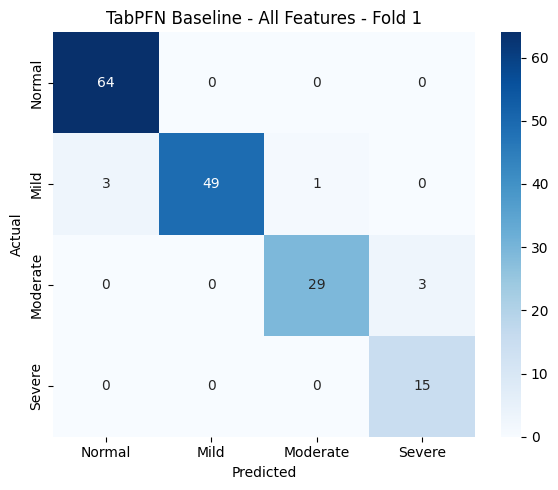

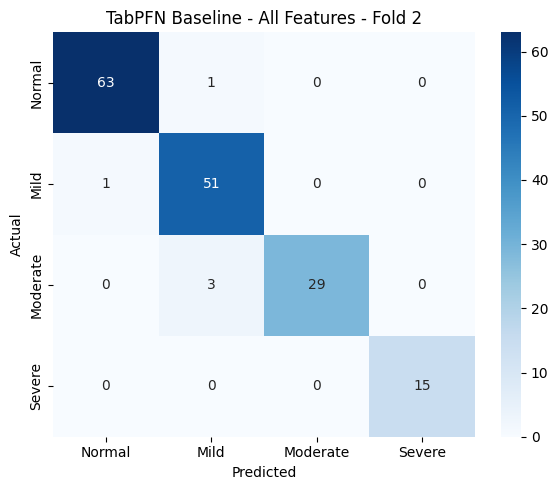

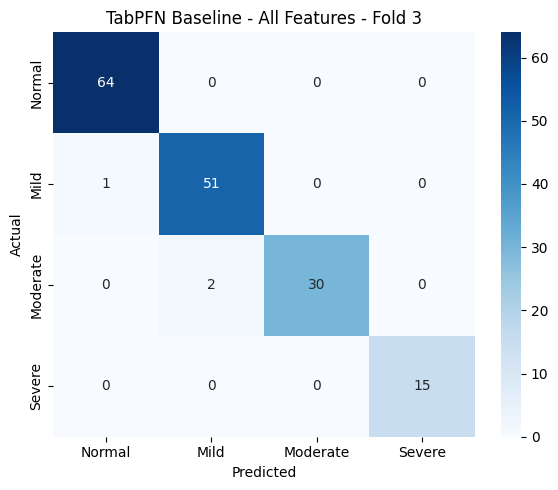

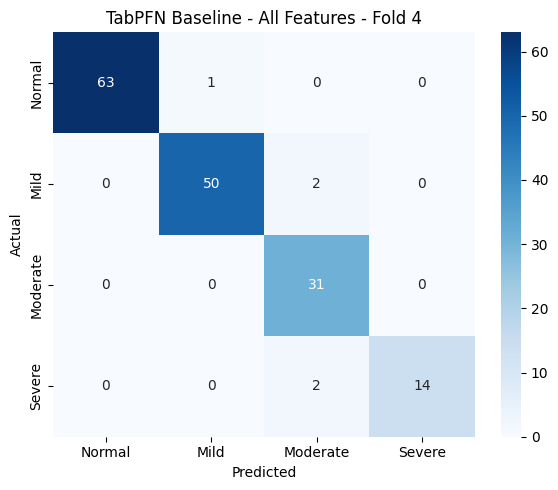

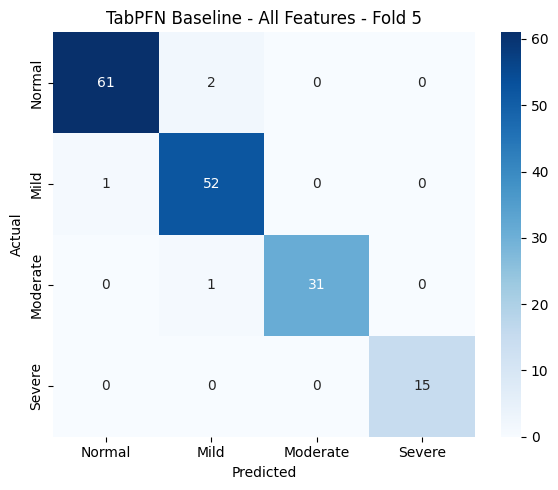


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.9706,0.968,0.9675,0.9677,0.9578,0.9978



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.9813,0.9875,0.9844,319.0000
Mild,0.9620,0.9656,0.9638,262.0000
Moderate,0.9677,0.9434,0.9554,159.0000
Severe,0.9610,0.9737,0.9673,76.0000
accuracy,0.9706,0.9706,0.9706,0.9706
macro avg,0.9680,0.9675,0.9677,816.0000
weighted avg,0.9706,0.9706,0.9705,816.0000



Aggregated Confusion Matrix


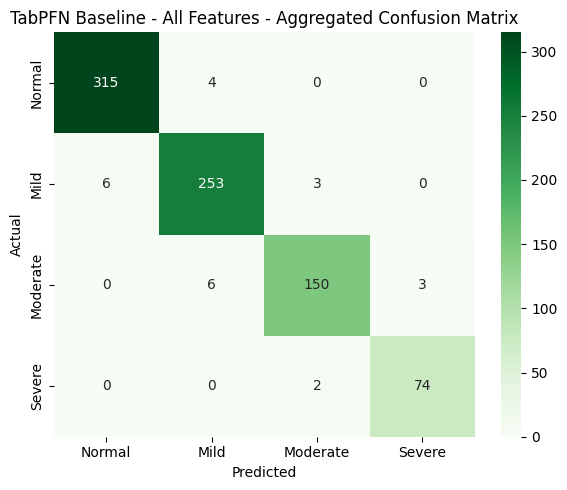

In [42]:
tabpfn_all_results, tabpfn_all_reports, tabpfn_all_agg_metrics, tabpfn_all_agg_report, tabpfn_all_cm = run_tabpfn_stratified_cv(
    X=X_train,
    y=y_train,
    experiment_name='TabPFN Baseline - All Features'
)

### SELECTED FEATURES


Experiment: TabPFN - Selected Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.9695,0.9549,0.9702,0.9613,0.9568,0.9838
1,2,0.9632,0.9738,0.9600,0.9655,0.9478,1.0000
2,3,0.9693,0.9626,0.9669,0.9643,0.9561,1.0000
3,4,0.9693,0.9678,0.9520,0.9586,0.9563,1.0000
4,5,0.9693,0.9667,0.9717,0.9686,0.9563,1.0000



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.969697,1.000000,0.984615,64.000000
Mild,1,1.000000,0.943396,0.970874,53.000000
Moderate,1,0.967742,0.937500,0.952381,32.000000
Severe,1,0.882353,1.000000,0.937500,15.000000
accuracy,1,0.969512,0.969512,0.969512,0.969512
macro avg,1,0.954948,0.970224,0.961343,164.000000
weighted avg,1,0.971120,0.969512,0.969576,164.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,1.000000,0.984375,0.992126,64.000000
Mild,4,0.962264,0.980769,0.971429,52.000000
Moderate,4,0.909091,0.967742,0.937500,31.000000
Severe,4,1.000000,0.875000,0.933333,16.000000
accuracy,4,0.969325,0.969325,0.969325,0.969325
macro avg,4,0.967839,0.951972,0.958597,163.000000
weighted avg,4,0.970672,0.969325,0.969363,163.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.983871,0.968254,0.976000,63.000000
Mild,5,0.945455,0.981132,0.962963,53.000000
Moderate,5,1.000000,0.937500,0.967742,32.000000
Severe,5,0.937500,1.000000,0.967742,15.000000
accuracy,5,0.969325,0.969325,0.969325,0.969325
macro avg,5,0.966706,0.971722,0.968612,163.000000
weighted avg,5,0.970279,0.969325,0.969380,163.000000



Confusion Matrices for Each Fold


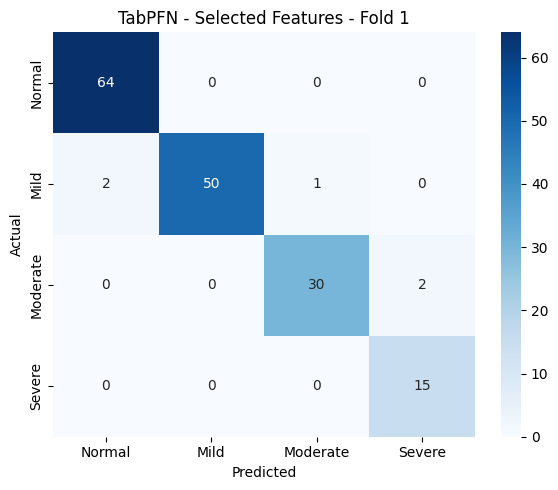

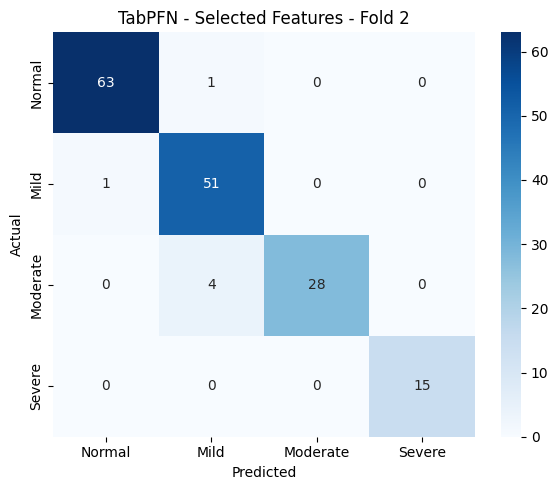

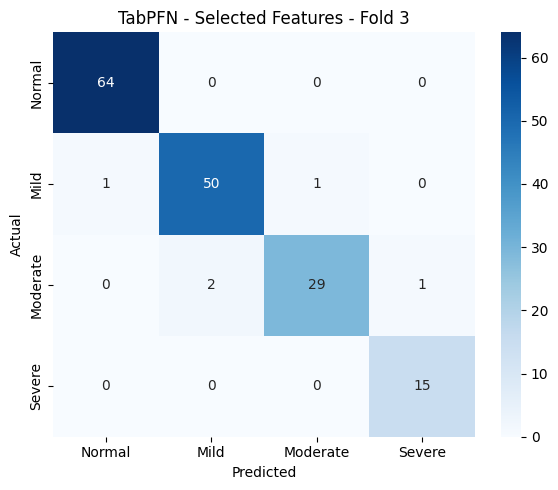

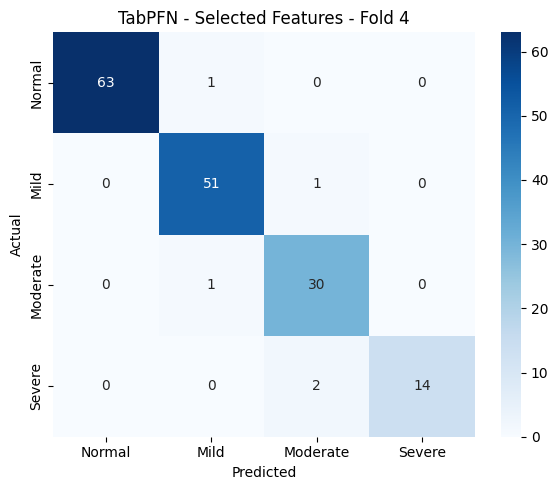

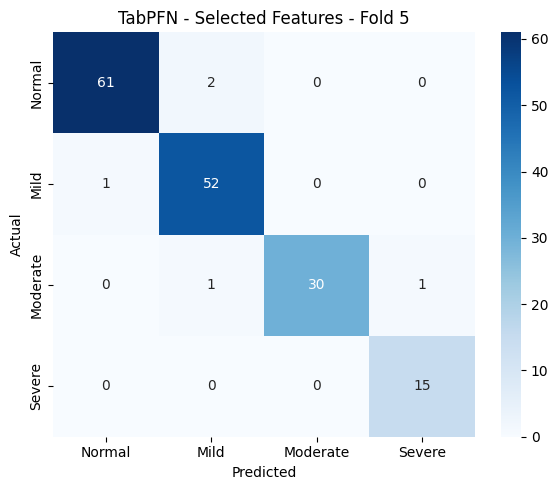


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.9681,0.9638,0.9638,0.9636,0.9543,0.9929



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.9844,0.9875,0.9859,319.0000
Mild,0.9549,0.9695,0.9621,262.0000
Moderate,0.9671,0.9245,0.9453,159.0000
Severe,0.9487,0.9737,0.9610,76.0000
accuracy,0.9681,0.9681,0.9681,0.9681
macro avg,0.9638,0.9638,0.9636,816.0000
weighted avg,0.9682,0.9681,0.9681,816.0000



Aggregated Confusion Matrix


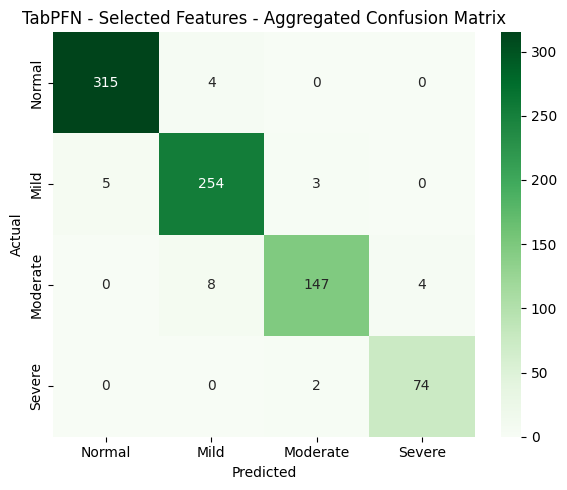

In [43]:
selected_features = [
    'Motor Latency ms',
    'Motor Amplitude mV',
    'Motor Conduction Velocity mps',
    'Sensory Latency ms',
    'Sensory Amplitude uV',
    'Sensory Conduction Velocity mps',
    'F Wave Latency ms'

]

X_train_selected = X_train[selected_features].copy()

tabpfn_selected_results, tabpfn_selected_reports, tabpfn_selected_agg_metrics, tabpfn_selected_agg_report, tabpfn_selected_cm = run_tabpfn_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='TabPFN - Selected Features'
)

# Comparison

In [44]:
tabpfn_comparison = pd.DataFrame({
    'All Features': tabpfn_all_results.drop(columns='Fold').mean(),
    'Selected Features': tabpfn_selected_results.drop(columns='Fold').mean()
})

print("TabPFN Baseline Comparison")
display(tabpfn_comparison)

TabPFN Baseline Comparison


,All Features,Selected Features
Accuracy,0.97060,0.96812
Precision_macro,0.97044,0.96516
Recall_macro,0.96796,0.96416
F1_macro,0.96806,0.96366
MCC,0.95830,0.95466
AP_Severe,0.99844,0.99676


In [45]:
print("All Features - Aggregated Classification Report")
display(tabpfn_all_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

print("-" * 100)

print("\nSelected Features - Aggregated Classification Report")
display(tabpfn_selected_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

All Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.9813,0.9875,0.9844,319.0000
Mild,0.9620,0.9656,0.9638,262.0000
Moderate,0.9677,0.9434,0.9554,159.0000
Severe,0.9610,0.9737,0.9673,76.0000
accuracy,0.9706,0.9706,0.9706,0.9706
macro avg,0.9680,0.9675,0.9677,816.0000
weighted avg,0.9706,0.9706,0.9705,816.0000


----------------------------------------------------------------------------------------------------

Selected Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.9844,0.9875,0.9859,319.0000
Mild,0.9549,0.9695,0.9621,262.0000
Moderate,0.9671,0.9245,0.9453,159.0000
Severe,0.9487,0.9737,0.9610,76.0000
accuracy,0.9681,0.9681,0.9681,0.9681
macro avg,0.9638,0.9638,0.9636,816.0000
weighted avg,0.9682,0.9681,0.9681,816.0000


# Final TabPFN Model (EMG)

## Reatrin on full train set

In [46]:
# Select final dataset (Selected Features only)
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

# Clean feature names for consistency
X_train_final.columns = X_train_final.columns.str.replace(' ', '_')
X_test_final.columns = X_test_final.columns.str.replace(' ', '_')

# Debug shapes and features
print("Final training shape :", X_train_final.shape)
print("Final testing shape  :", X_test_final.shape)
print("Selected features    :", list(X_train_final.columns))

Final training shape : (816, 7)
Final testing shape  : (204, 7)
Selected features    : ['Motor_Latency_ms', 'Motor_Amplitude_mV', 'Motor_Conduction_Velocity_mps', 'Sensory_Latency_ms', 'Sensory_Amplitude_uV', 'Sensory_Conduction_Velocity_mps', 'F_Wave_Latency_ms']


In [47]:
# Define target mapping
target_mapping = {
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

# Convert y if still text
if y_train.dtype == 'object':
    y_train_final = y_train.map(target_mapping)
else:
    y_train_final = y_train.copy()

if y_test.dtype == 'object':
    y_test_final = y_test.map(target_mapping)
else:
    y_test_final = y_test.copy()

print("Unique train labels:", sorted(y_train_final.unique()))
print("Unique test labels :", sorted(y_test_final.unique()))

Unique train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unique test labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [48]:
from tabpfn import TabPFNClassifier

# Build final TabPFN model
final_tabpfn_model = TabPFNClassifier()

# Train final model on the full training set
final_tabpfn_model.fit(X_train_final, y_train_final)

print("Final TabPFN model has been trained on the full training set.")

Final TabPFN model has been trained on the full training set.


## Test set evaluation

In [49]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score
)
import pandas as pd

# Class names and labels
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
class_labels = [0, 1, 2, 3]

# Severe class info
severe_label = 3
severe_index = class_labels.index(severe_label)

# Predict on test set
y_test_pred = final_tabpfn_model.predict(X_test_final)
y_test_proba = final_tabpfn_model.predict_proba(X_test_final)

# Compute test metrics
test_accuracy = accuracy_score(y_test_final, y_test_pred)
test_precision_macro = precision_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_mcc = matthews_corrcoef(y_test_final, y_test_pred)

# Compute Average Precision for Severe class
y_test_severe = (y_test_final == severe_label).astype(int)
y_test_proba_severe = y_test_proba[:, severe_index]
test_ap_severe = average_precision_score(y_test_severe, y_test_proba_severe)

# Store test metrics
test_metrics_df = pd.DataFrame([{
    'Accuracy': round(test_accuracy, 4),
    'Precision_macro': round(test_precision_macro, 4),
    'Recall_macro': round(test_recall_macro, 4),
    'F1_macro': round(test_f1_macro, 4),
    'MCC': round(test_mcc, 4),
    'AP_Severe': round(test_ap_severe, 4)
}])

print("Final TabPFN - Test Set Metrics")
display(test_metrics_df)

Final TabPFN - Test Set Metrics


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.9804,0.9869,0.9853,0.986,0.972,1.0


In [50]:
from sklearn.metrics import classification_report
import pandas as pd

# Build classification report
test_report_dict = classification_report(
    y_test_final,
    y_test_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose().round(4)

print("Final TabPFN - Test Classification Report")
display(test_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

Final TabPFN - Test Classification Report


,precision,recall,f1-score,support
Normal,0.9634,0.9875,0.9753,80.0000
Mild,0.9841,0.9538,0.9688,65.0000
Moderate,1.0000,1.0000,1.0000,40.0000
Severe,1.0000,1.0000,1.0000,19.0000
accuracy,0.9804,0.9804,0.9804,0.9804
macro avg,0.9869,0.9853,0.9860,204.0000
weighted avg,0.9806,0.9804,0.9804,204.0000


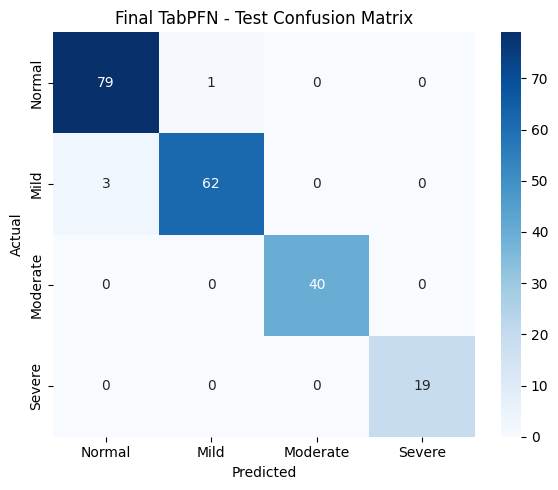

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
test_cm = confusion_matrix(y_test_final, y_test_pred, labels=class_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final TabPFN - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Explainable AI

In [52]:
FEATURES = X_train_final.columns.tolist()

print(FEATURES)
print(X_train_final.shape)
print(X_test_final.shape)

['Motor_Latency_ms', 'Motor_Amplitude_mV', 'Motor_Conduction_Velocity_mps', 'Sensory_Latency_ms', 'Sensory_Amplitude_uV', 'Sensory_Conduction_Velocity_mps', 'F_Wave_Latency_ms']
(816, 7)
(204, 7)


In [53]:
X_explain = X_test_final.sample(50, random_state=42)

shap_values = interpretability.shap.get_shap_values(
    estimator=final_tabpfn_model,
    test_x=X_explain,
    attribute_names=FEATURES,
    algorithm="permutation"
)

PermutationExplainer explainer: 51it [15:22, 18.44s/it]


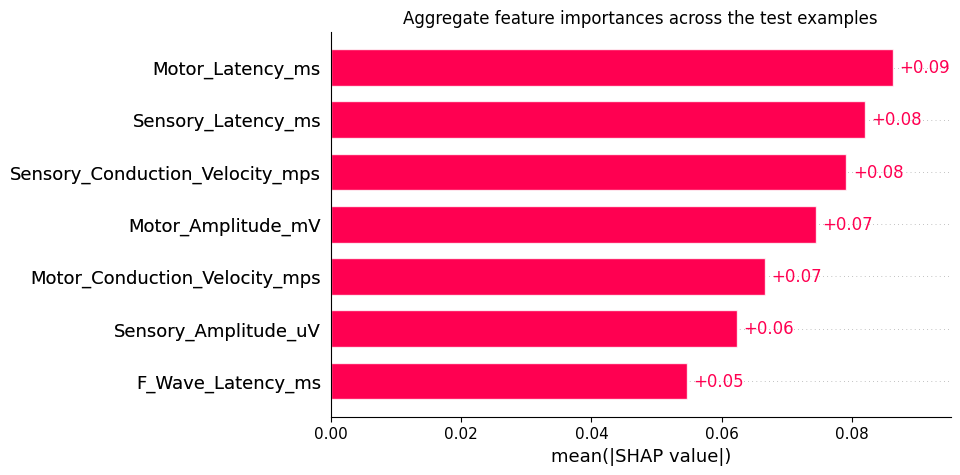

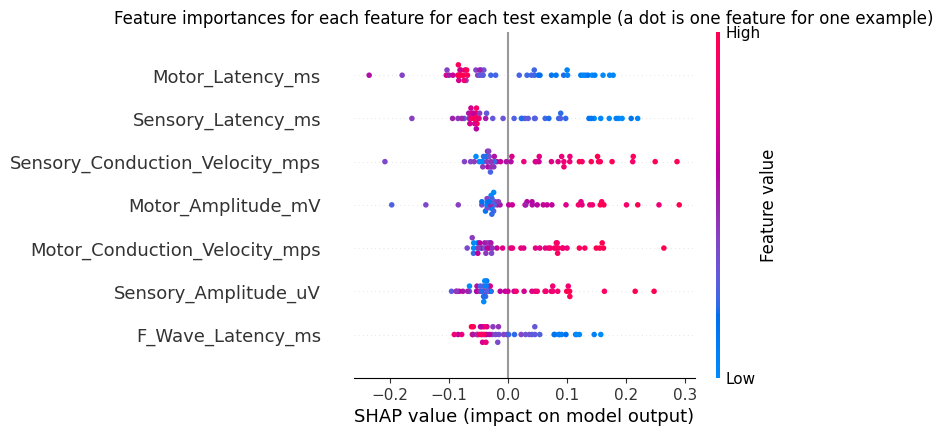

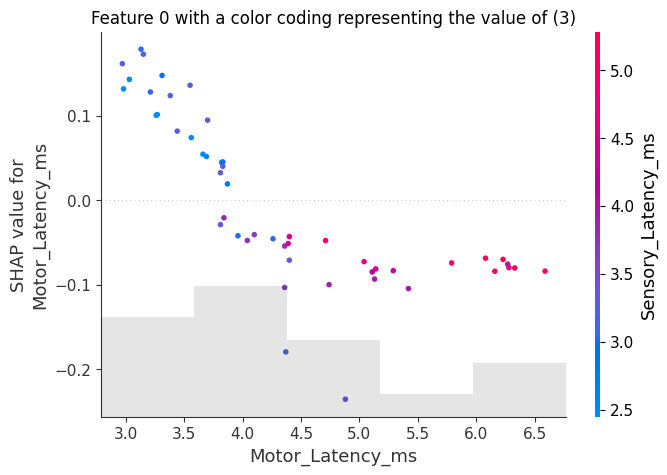

In [54]:
fig = interpretability.shap.plot_shap(shap_values)
plt.show()


SHAP for class: Normal


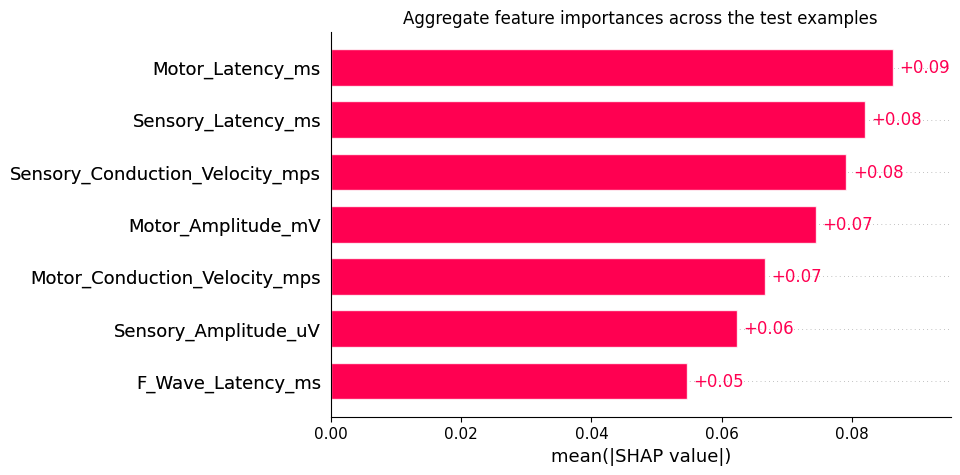

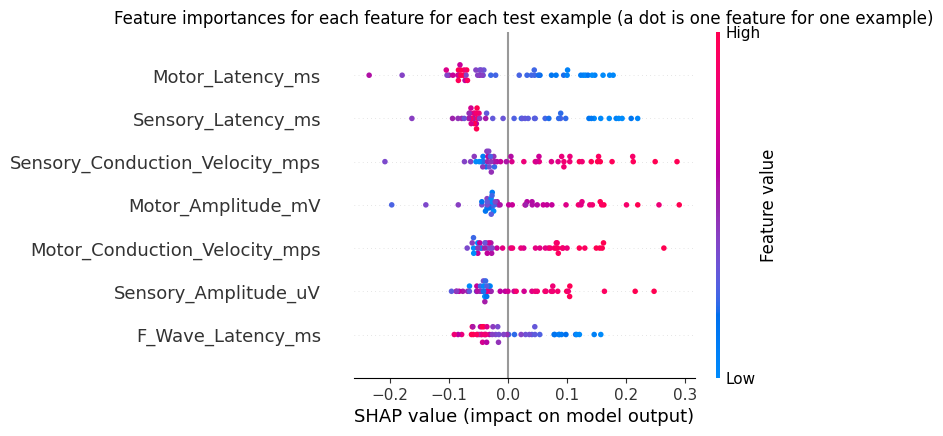

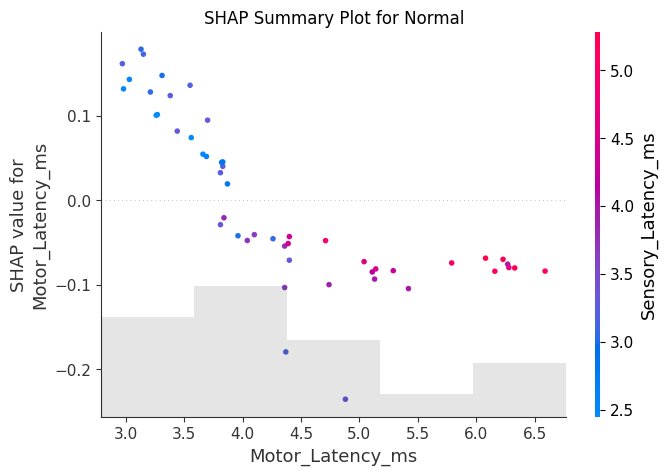


SHAP for class: Mild


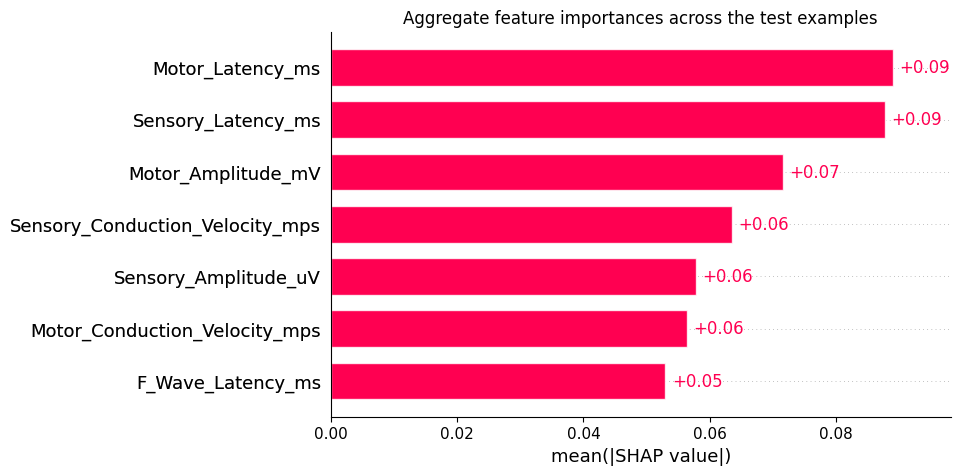

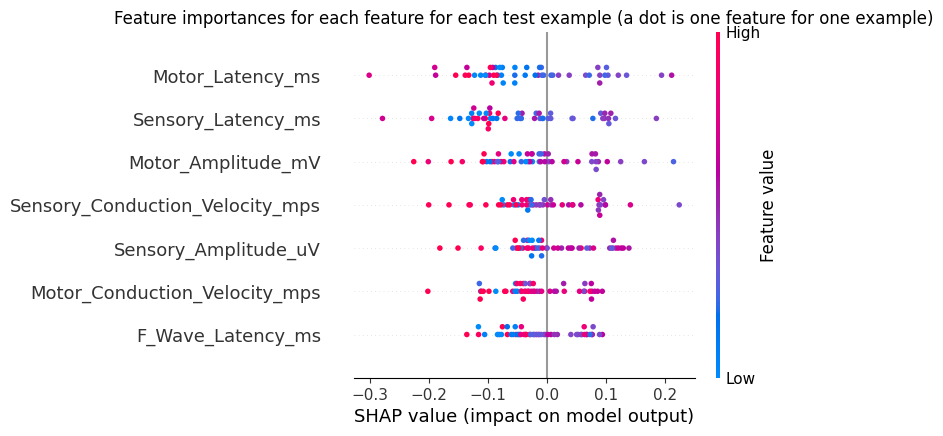

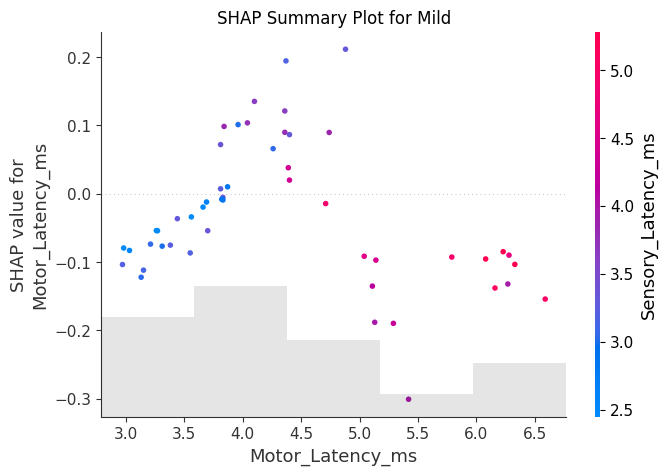


SHAP for class: Moderate


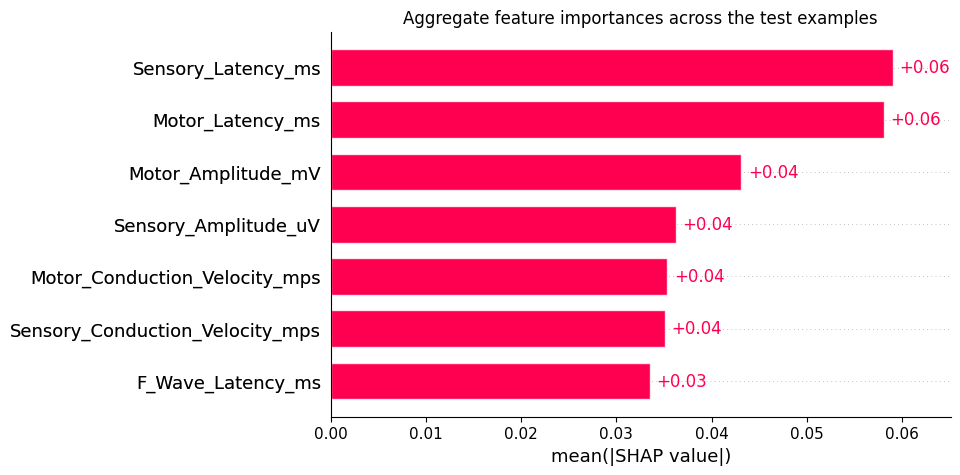

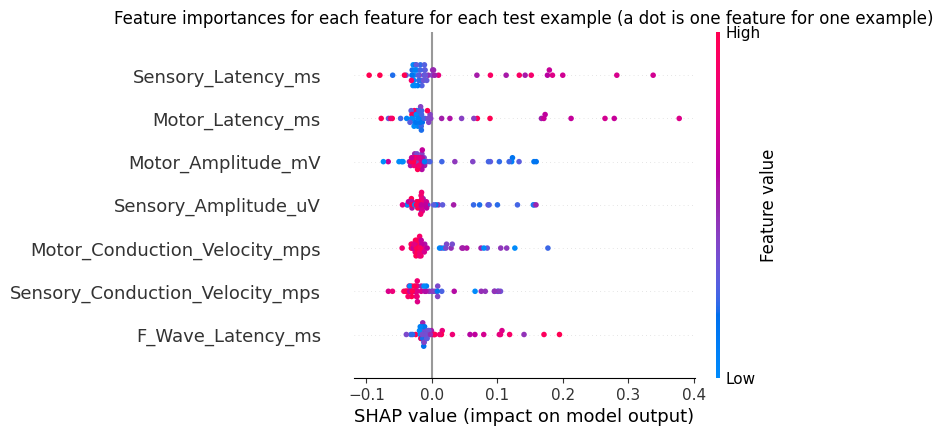

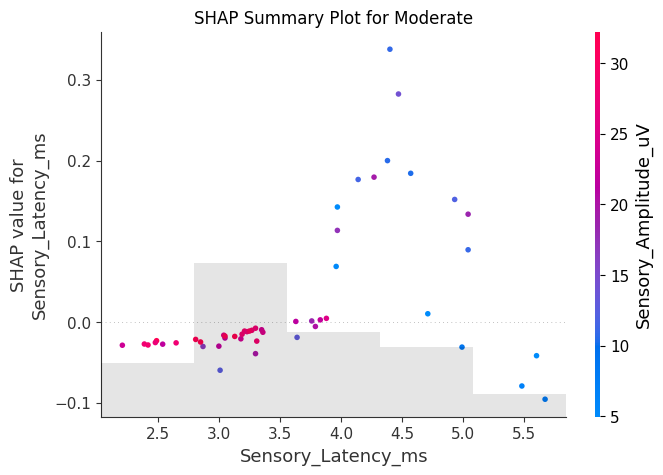


SHAP for class: Severe


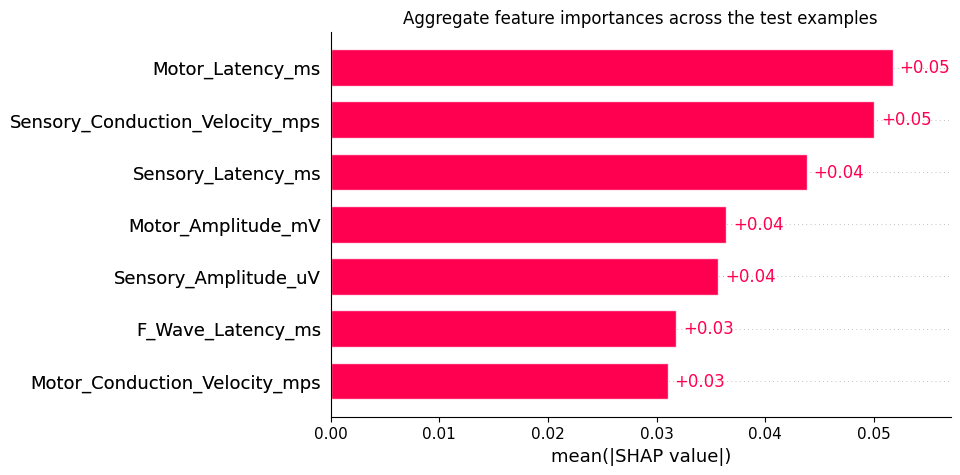

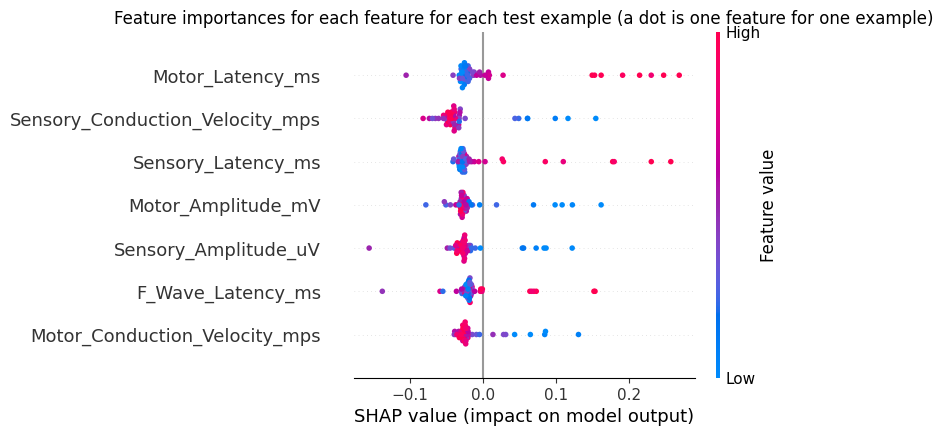

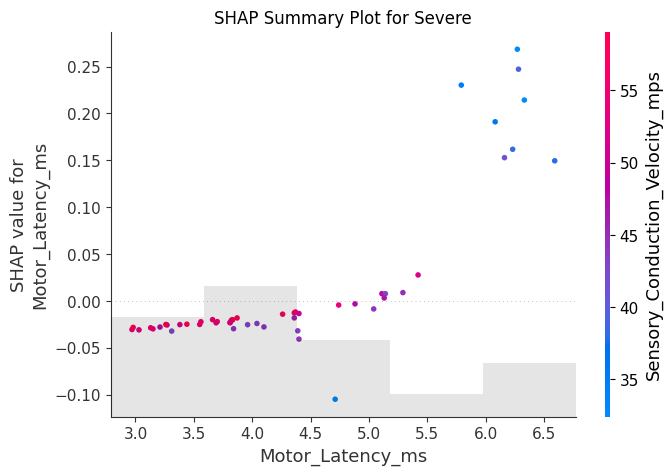

In [55]:
class_names = ["Normal", "Mild", "Moderate", "Severe"]

for i, class_name in enumerate(class_names):
    print(f"\nSHAP for class: {class_name}")

    shap_class = shap_values[..., i]

    fig = interpretability.shap.plot_shap(shap_class)
    plt.title(f"SHAP Summary Plot for {class_name}")
    plt.show()

In [56]:
values = shap_values.values

importance_all = []

for i, class_name in enumerate(class_names):
    importance = np.mean(np.abs(values[..., i]), axis=0)
    importance_all.append(importance)

tabpfn_importance_df = pd.DataFrame(
    np.array(importance_all).T,
    index=FEATURES,
    columns=class_names
)

tabpfn_importance_df

,Normal,Mild,Moderate,Severe
Motor_Latency_ms,0.086265,0.089017,0.058070,0.051777
Motor_Amplitude_mV,0.074367,0.071607,0.043114,0.036438
Motor_Conduction_Velocity_mps,0.066564,0.056371,0.035350,0.031030
Sensory_Latency_ms,0.081922,0.087750,0.059051,0.043861
Sensory_Amplitude_uV,0.062312,0.057773,0.036256,0.035689
Sensory_Conduction_Velocity_mps,0.079070,0.063540,0.035075,0.050035
F_Wave_Latency_ms,0.054583,0.052981,0.033523,0.031805


## Overfitting check

In [57]:
# Extract TabPFN CV aggregated metrics
best_cv_accuracy = tabpfn_selected_agg_metrics.loc[0, 'Accuracy']
best_cv_precision_macro = tabpfn_selected_agg_metrics.loc[0, 'Precision_macro']
best_cv_recall_macro = tabpfn_selected_agg_metrics.loc[0, 'Recall_macro']
best_cv_f1_macro = tabpfn_selected_agg_metrics.loc[0, 'F1_macro']
best_cv_mcc = tabpfn_selected_agg_metrics.loc[0, 'MCC']
best_cv_ap_severe = tabpfn_selected_agg_metrics.loc[0, 'AP_Severe']

# CV vs Test comparison
cv_vs_test_tabpfn_df = pd.DataFrame([
    ['CV', best_cv_accuracy, best_cv_precision_macro, best_cv_recall_macro, best_cv_f1_macro, best_cv_mcc, best_cv_ap_severe],
    ['Test Set', test_accuracy, test_precision_macro, test_recall_macro, test_f1_macro, test_mcc, test_ap_severe]
], columns=['Dataset', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'MCC', 'AP_Severe'])

cv_vs_test_tabpfn_df.iloc[:, 1:] = cv_vs_test_tabpfn_df.iloc[:, 1:].round(4)

print("CV vs Test Set")
display(cv_vs_test_tabpfn_df)

CV vs Test Set


,Dataset,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,CV,0.9681,0.9638,0.9638,0.9636,0.9543,0.9929
1,Test Set,0.9804,0.9869,0.9853,0.9860,0.9720,1.0000


In [58]:
# Compute generalization gap (CV - Test)

tabpfn_gap_df = pd.DataFrame([{
    'Accuracy_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Accuracy'] - test_accuracy, 4),
    'Precision_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Precision_macro'] - test_precision_macro, 4),
    'Recall_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Recall_macro'] - test_recall_macro, 4),
    'F1_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'F1_macro'] - test_f1_macro, 4),
    'MCC_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'MCC'] - test_mcc, 4),
    'AP_Severe_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'AP_Severe'] - test_ap_severe, 4)
}])

print("Overfitting Check (CV - Test)")
display(tabpfn_gap_df)

Overfitting Check (CV - Test)


,Accuracy_Gap,Precision_macro_Gap,Recall_macro_Gap,F1_macro_Gap,MCC_Gap,AP_Severe_Gap
0,-0.0123,-0.0231,-0.0215,-0.0224,-0.0177,-0.0071


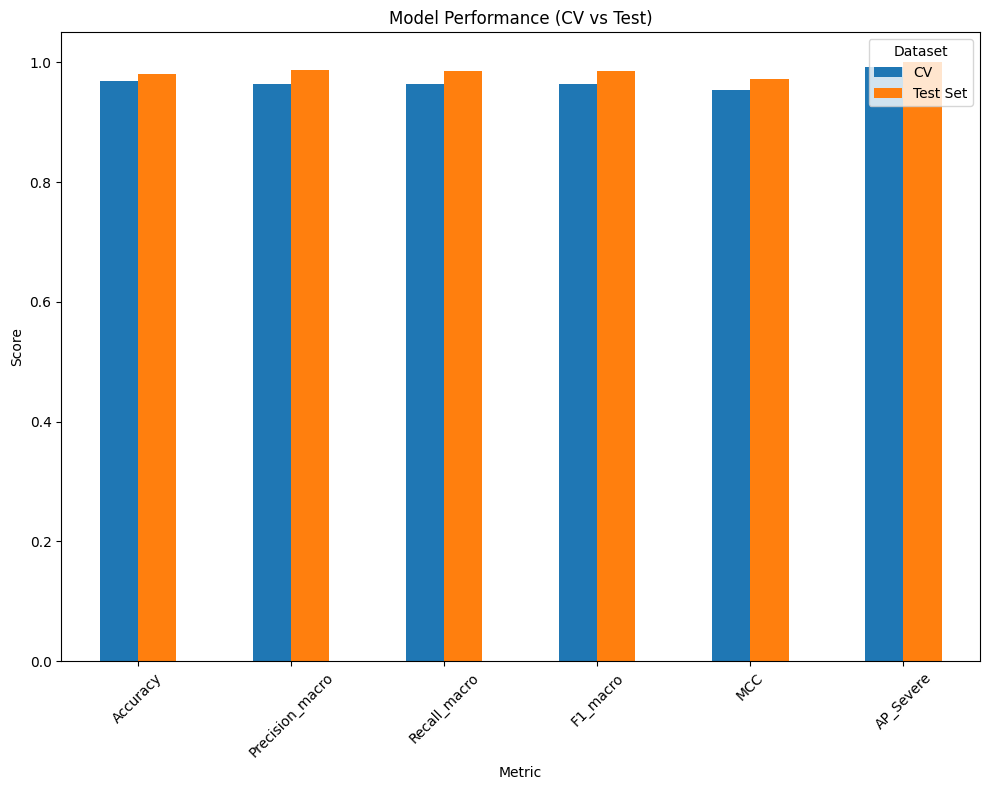

In [59]:
# Prepare data for plotting
plot_df = cv_vs_test_tabpfn_df.set_index('Dataset').T

# Plot comparison
plot_df.plot(kind='bar', figsize=(10, 8))

plt.title("Model Performance (CV vs Test)")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.xticks(rotation=45)
plt.ylim(0, 1.05)

plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

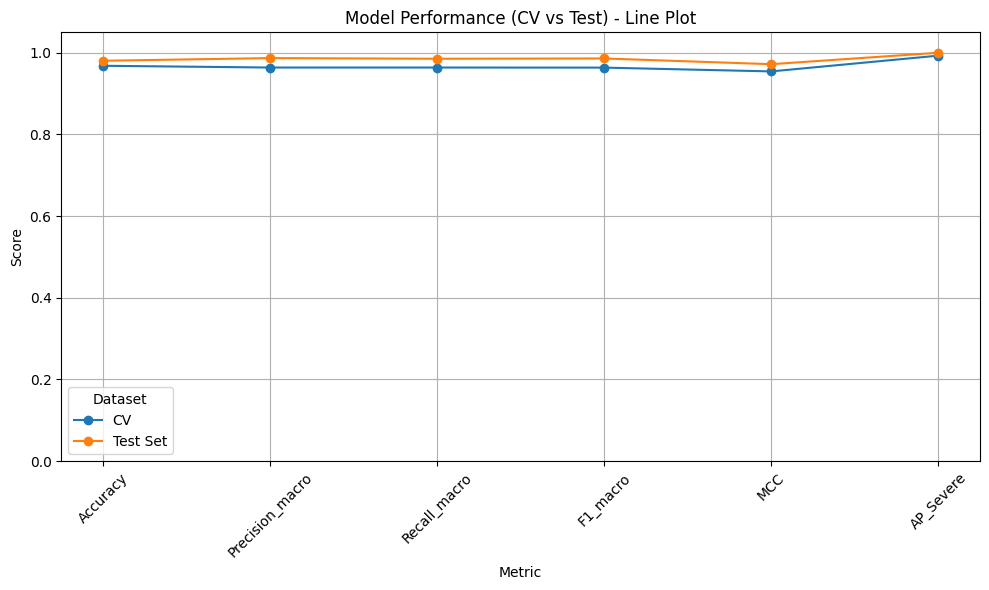

In [60]:
# Prepare data
plot_df = cv_vs_test_tabpfn_df.set_index('Dataset').T

# Line plot
plot_df.plot(marker='o', figsize=(10, 6))

plt.title("Model Performance (CV vs Test) - Line Plot")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.xticks(rotation=45)
plt.ylim(0, 1.05)

plt.legend(title="Dataset")
plt.grid(True)

plt.tight_layout()
plt.show()

## Test Set Sample predictions

In [61]:
# Map numeric labels to class names
label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

# Build comparison table
sample_predictions_named = pd.DataFrame({
    'Actual': y_test_final.map(label_names).values,
    'Predicted': pd.Series(y_test_pred, index=y_test_final.index).map(label_names).values
}, index=y_test_final.index)

print("Sample Predictions with Class Names")
display(sample_predictions_named.head(10))

Sample Predictions with Class Names


,Actual,Predicted
167,Mild,Mild
1014,Normal,Normal
944,Normal,Normal
124,Normal,Normal
12,Severe,Severe
790,Normal,Normal
24,Severe,Severe
1006,Normal,Normal
41,Mild,Mild
254,Moderate,Moderate


In [62]:
# Predict class labels
y_test_pred = final_tabpfn_model.predict(X_test_final)

# Predict probabilities
y_test_proba = final_tabpfn_model.predict_proba(X_test_final)

# Map numeric labels to class names
label_mapping = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

# Convert actual and predicted labels to names
sample_predictions_named = pd.DataFrame({
    'Actual': pd.Series(y_test_final).map(label_mapping),
    'Predicted': pd.Series(y_test_pred, index=y_test_final.index).map(label_mapping)
}, index=y_test_final.index)

# Create probability dataframe
proba_df = pd.DataFrame(
    y_test_proba,
    columns=['Prob_Normal', 'Prob_Mild', 'Prob_Moderate', 'Prob_Severe'],
    index=y_test_final.index
)

# Combine everything
prediction_with_proba = pd.concat([sample_predictions_named, proba_df], axis=1)

print("Sample Predictions with Probabilities - TabPFN")
display(prediction_with_proba.head(10))

Sample Predictions with Probabilities - TabPFN


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
167,Mild,Mild,3.922238e-04,0.999576,3.171171e-05,1.192169e-07
1014,Normal,Normal,9.999795e-01,0.000020,0.000000e+00,0.000000e+00
944,Normal,Normal,9.999444e-01,0.000055,5.960133e-08,0.000000e+00
124,Normal,Normal,9.999099e-01,0.000090,1.191985e-07,0.000000e+00
12,Severe,Severe,7.154252e-07,0.000006,1.531124e-01,8.468803e-01
790,Normal,Normal,9.999864e-01,0.000014,0.000000e+00,0.000000e+00
24,Severe,Severe,2.980522e-07,0.000001,8.779425e-04,9.991206e-01
1006,Normal,Normal,9.999844e-01,0.000016,0.000000e+00,0.000000e+00
41,Mild,Mild,4.320062e-02,0.956760,3.885120e-05,1.012991e-06
254,Moderate,Moderate,1.788329e-06,0.000045,9.668994e-01,3.305404e-02


In [63]:
# Show only incorrect predictions
errors_df = prediction_with_proba[
    prediction_with_proba['Actual'] != prediction_with_proba['Predicted']
]

print("Misclassified Samples")
display(errors_df.head(10))

Misclassified Samples


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
49,Normal,Mild,0.023896,0.976093,0.000010,2.980291e-07
856,Mild,Normal,0.722343,0.277655,0.000001,1.788573e-07
181,Mild,Normal,0.779783,0.220214,0.000002,3.576271e-07
571,Mild,Normal,0.670083,0.329913,0.000004,2.980947e-07


# Save the full model

## Train on Full Dataset( Train + Test)

In [64]:
# Combine train + test for final deployment model
X_full_selected = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_full = pd.concat([y_train, y_test], axis=0)

# Reset index
X_full_selected = X_full_selected.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# Clean feature names for consistency
X_full_selected.columns = X_full_selected.columns.str.replace(' ', '_')

print("Full dataset shape :", X_full_selected.shape)
print("Full target shape  :", y_full.shape)
print("Selected features  :", list(X_full_selected.columns))

Full dataset shape : (1020, 7)
Full target shape  : (1020,)
Selected features  : ['Motor_Latency_ms', 'Motor_Amplitude_mV', 'Motor_Conduction_Velocity_mps', 'Sensory_Latency_ms', 'Sensory_Amplitude_uV', 'Sensory_Conduction_Velocity_mps', 'F_Wave_Latency_ms']


In [65]:
# Define target mapping
target_mapping = {
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

# Convert y if still text
if y_full.dtype == 'object':
    y_full_final = y_full.map(target_mapping)
else:
    y_full_final = y_full.copy()

print("Unique full labels:", sorted(y_full_final.unique()))

Unique full labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [66]:
from tabpfn import TabPFNClassifier

# Build final deployment TabPFN model
final_deployment_tabpfn_model = TabPFNClassifier()

# Train on full dataset
final_deployment_tabpfn_model.fit(X_full_selected, y_full_final)

print("Final deployment TabPFN model has been trained on the full dataset.")

Final deployment TabPFN model has been trained on the full dataset.


In [67]:
import joblib

deployment_bundle = {
    'model': final_deployment_tabpfn_model,
    'selected_features': list(X_full_selected.columns),
    'label_names': {
        0: 'Normal',
        1: 'Mild',
        2: 'Moderate',
        3: 'Severe'
    }
}

joblib.dump(deployment_bundle, 'final_tabpfn_deployment_bundle_NCS.pkl')

print("Deployment bundle saved successfully.")

Deployment bundle saved successfully.


In [68]:
# Load the saved bundle
deployment_bundle = joblib.load('final_tabpfn_deployment_bundle_NCS.pkl')

loaded_model = deployment_bundle['model']
loaded_selected_features = deployment_bundle['selected_features']
loaded_label_names = deployment_bundle['label_names']

print("Bundle loaded successfully.")
print("Loaded selected features:", loaded_selected_features)
print("Loaded label names:", loaded_label_names)

Bundle loaded successfully.
Loaded selected features: ['Motor_Latency_ms', 'Motor_Amplitude_mV', 'Motor_Conduction_Velocity_mps', 'Sensory_Latency_ms', 'Sensory_Amplitude_uV', 'Sensory_Conduction_Velocity_mps', 'F_Wave_Latency_ms']
Loaded label names: {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}


# New sample prediction

In [69]:
# New unseen sample
new_sample = pd.DataFrame([{
    'Motor Latency ms' : 4.83 ,
    'Motor Amplitude mV' : 3.42 ,
    'Motor Conduction Velocity mps' : 24.6,
    'Sensory Latency ms': 4.17 ,
    'Sensory Amplitude uV' : 7 ,
    'Sensory Conduction Velocity mps' : 37.3,
    'F Wave Latency ms' : 38.3
}])

# Clean column names to match training
new_sample.columns = new_sample.columns.str.replace(' ', '_')

# Use loaded selected features and keep same order
new_sample = new_sample[loaded_selected_features].copy()

# Predict
new_prediction = loaded_model.predict(new_sample)[0]
new_prediction_proba = loaded_model.predict_proba(new_sample)[0]

print("EMG Input Values:")
for col, val in new_sample.iloc[0].items():
    print(f"{col}: {val}")

print("\nPredicted Strength Severity:")
print(f"{loaded_label_names[new_prediction]}")

print("\nConfidence Scores Across Classes:")
for i, prob in enumerate(new_prediction_proba):
    class_name = loaded_label_names[i]
    print(f"{class_name:9}: {prob*100:.1f}%")

EMG Input Values:
Motor_Latency_ms: 4.83
Motor_Amplitude_mV: 3.42
Motor_Conduction_Velocity_mps: 24.6
Sensory_Latency_ms: 4.17
Sensory_Amplitude_uV: 7.0
Sensory_Conduction_Velocity_mps: 37.3
F_Wave_Latency_ms: 38.3

Predicted Strength Severity:
Severe

Confidence Scores Across Classes:
Normal   : 0.0%
Mild     : 0.0%
Moderate : 17.0%
Severe   : 83.0%
